In [3]:
pip install pyodbc


Note: you may need to restart the kernel to use updated packages.


In [4]:
pip install pandas

Note: you may need to restart the kernel to use updated packages.


In [5]:
import pyodbc

conn = pyodbc.connect(
    "DRIVER={ODBC Driver 18 for SQL Server};"
    "SERVER=localhost;"
    "DATABASE=TestDB;"
    "Trusted_Connection=yes;"
)

OperationalError: ('08001', '[08001] [Microsoft][ODBC Driver 18 for SQL Server]SSL Provider: The certificate chain was issued by an authority that is not trusted.\r\n (-2146893019) (SQLDriverConnect); [08001] [Microsoft][ODBC Driver 18 for SQL Server]Client unable to establish connection. For solutions related to encryption errors, see https://go.microsoft.com/fwlink/?linkid=2226722 (-2146893019)')

In [6]:
conn = pyodbc.connect(
    "DRIVER={ODBC Driver 18 for SQL Server};"
    "SERVER=localhost;"
    "DATABASE=TestDB;"
    "Trusted_Connection=yes;"
    "Encrypt=yes;"
    "TrustServerCertificate=yes;"
)

In [7]:
conn = pyodbc.connect(
    "DRIVER={ODBC Driver 18 for SQL Server};"
    "SERVER=localhost;"
    "DATABASE=TestDB;"
    "Trusted_Connection=yes;"
    "Encrypt=no;"
)

In [8]:
cursor.execute("SELECT @@VERSION")
print(cursor.fetchone()[0])

NameError: name 'cursor' is not defined

In [9]:
import pyodbc

conn = pyodbc.connect(
    "DRIVER={ODBC Driver 18 for SQL Server};"
    "SERVER=localhost;"
    "DATABASE=TestDB;"
    "Trusted_Connection=yes;"
    "Encrypt=yes;"
    "TrustServerCertificate=yes;"
)

cursor = conn.cursor()

cursor.execute("SELECT @@VERSION")
row = cursor.fetchone()

print(row[0])

conn.close()

Microsoft SQL Server 2025 (RTM) - 17.0.1000.7 (X64) 
	Oct 21 2025 12:05:57 
	Copyright (C) 2025 Microsoft Corporation
	Standard Developer Edition (64-bit) on Windows 10 Home Single Language 10.0 <X64> (Build 19045: )



In [10]:
cursor.execute("SELECT * FROM ASSOMASTER")


ProgrammingError: The cursor's connection has been closed.

In [11]:
import pyodbc

conn = pyodbc.connect(
    "DRIVER={ODBC Driver 18 for SQL Server};"
    "SERVER=localhost;"
    "DATABASE=TestDB;"
    "Trusted_Connection=yes;"
    "Encrypt=yes;"
    "TrustServerCertificate=yes;"
)

cursor = conn.cursor()

cursor.execute("SELECT * FROM ASSOMASTER")

rows = cursor.fetchall()

for row in rows:
    print(row)

conn.close()

In [12]:
import pyodbc

conn = pyodbc.connect(
    "DRIVER={ODBC Driver 18 for SQL Server};"
    "SERVER=localhost;"
    "DATABASE=Testing_db;"
    "Trusted_Connection=yes;"
    "Encrypt=yes;"
    "TrustServerCertificate=yes;"
)

cursor = conn.cursor()

cursor.execute("SELECT * FROM ASSOMASTER")

rows = cursor.fetchall()

for row in rows:
    print(row)

conn.close()

('ADMIN', 'Admin', 'C0000081', '', '', 'manvika.chaudhary@cogniscient.in', '123456789123', 'C0000032', '0', 'ADMIN', 'AGPACK    ', 'HEADOFFICE      ', 'C0000007', 'C0000336', '', datetime.datetime(2015, 4, 1, 0, 0), datetime.datetime(2024, 7, 25, 0, 0), 'ADMIN', datetime.datetime(1900, 1, 1, 0, 0), None, datetime.datetime(1900, 1, 1, 0, 0), 'LC2024', '', datetime.datetime(2015, 4, 1, 0, 0), datetime.datetime(1900, 1, 1, 0, 0), 'EMP', '', '123345456666', '                    ', '1', '1', datetime.datetime(2025, 8, 29, 12, 59, 38, 717000), datetime.datetime(2025, 8, 29, 12, 59, 38, 717000), 0, '  ', 'A-SHIFT', 'KOD1234', '', '', '', '', 'C0000057', 'C1', Decimal('0E-8'), 'C4', 'C2', '', 'Select', 'profile.png', 0, '', None, 'W', None, None, 'Select', None)
('AG00001', 'Gaurav Daga', 'C0000378', '', '9811832327', 'gaurav@agpolypacks.com', '919010034304211', 'C0000180', '0', 'AG00003', 'AGPACK    ', 'HEADOFFICE      ', 'C0000379', 'C0000056', '', datetime.datetime(2008, 4, 9, 0, 0), dateti

In [15]:
import requests

city = "Delhi"

url = "https://api.open-meteo.com/v1/forecast?latitude=28.61&longitude=77.20&current_weather=true"

response = requests.get(url)
data = response.json()

print(data)

import pandas as pd
df = pd.DataFrame(data)
print(df)

{'latitude': 28.576448, 'longitude': 77.18678, 'generationtime_ms': 0.09238719940185547, 'utc_offset_seconds': 0, 'timezone': 'GMT', 'timezone_abbreviation': 'GMT', 'elevation': 221.0, 'current_weather_units': {'time': 'iso8601', 'interval': 'seconds', 'temperature': '°C', 'windspeed': 'km/h', 'winddirection': '°', 'is_day': '', 'weathercode': 'wmo code'}, 'current_weather': {'time': '2026-06-27T20:45', 'interval': 900, 'temperature': 32.5, 'windspeed': 3.6, 'winddirection': 177, 'is_day': 0, 'weathercode': 0}}
                latitude  longitude  generationtime_ms  utc_offset_seconds  \
time           28.576448   77.18678           0.092387                   0   
interval       28.576448   77.18678           0.092387                   0   
temperature    28.576448   77.18678           0.092387                   0   
windspeed      28.576448   77.18678           0.092387                   0   
winddirection  28.576448   77.18678           0.092387                   0   
is_day         

In [18]:
import requests

def get_weather():
    url = "https://api.open-meteo.com/v1/forecast?latitude=28.61&longitude=77.20&current_weather=true"
    response = requests.get(url)
    data = response.json()

    weather = data["current_weather"]

    return {
        "city": "Delhi",
        "temperature": weather["temperature"],
        "windspeed": weather["windspeed"]
    }

print(get_weather())

{'city': 'Delhi', 'temperature': 32.5, 'windspeed': 3.6}


In [19]:
import pyodbc

def save_to_sql(data):
    conn = pyodbc.connect(
        "DRIVER={ODBC Driver 18 for SQL Server};"
        "SERVER=localhost;"
        "DATABASE=TestDB;"
        "Trusted_Connection=yes;"
        "Encrypt=yes;"
        "TrustServerCertificate=yes;"
    )

    cursor = conn.cursor()

    cursor.execute("""
        INSERT INTO WeatherHistory (City, Temperature, WindSpeed)
        VALUES (?, ?, ?)
    """, data["city"], data["temperature"], data["windspeed"])

    conn.commit()
    conn.close()

In [23]:
import pyodbc

def save_to_sql(data):
    try:
        conn = pyodbc.connect(
            "DRIVER={ODBC Driver 18 for SQL Server};"
            "SERVER=localhost;"
            "DATABASE=TestDB;"
            "Trusted_Connection=yes;"
            "Encrypt=yes;"
            "TrustServerCertificate=yes;"
        )

        cursor = conn.cursor()

        cursor.execute("""
            INSERT INTO WeatherHistory (City, Temperature, WindSpeed)
            VALUES (?, ?, ?)
        """, data["city"], data["temperature"], data["windspeed"])

        conn.commit()

        print("Data inserted successfully!")

    except Exception as e:
        print("❌ Error:", e)

    finally:
        conn.close()

In [22]:
print("Fetching weather data...")

Fetching weather data...


In [24]:
def save_to_sql(data):
    ...

In [25]:
data = {
    "city": "Delhi",
    "temperature": 35,
    "windspeed": 10
}

save_to_sql(data)

In [26]:
import pyodbc

def save_to_sql(data):
    print("Function started...")  # DEBUG

    try:
        conn = pyodbc.connect(
            "DRIVER={ODBC Driver 18 for SQL Server};"
            "SERVER=localhost;"
            "DATABASE=TestDB;"
            "Trusted_Connection=yes;"
            "Encrypt=yes;"
            "TrustServerCertificate=yes;"
        )

        print("Connected to SQL Server")  # DEBUG

        cursor = conn.cursor()

        cursor.execute("""
            INSERT INTO WeatherHistory (City, Temperature, WindSpeed)
            VALUES (?, ?, ?)
        """, data["city"], data["temperature"], data["windspeed"])

        conn.commit()

        print("✅ Data inserted successfully!")

    except Exception as e:
        print("❌ Error:", e)

    finally:
        conn.close()
        print("Connection closed")

In [27]:
data = {
    "city": "Delhi",
    "temperature": 35,
    "windspeed": 12
}

save_to_sql(data)

Function started...
Connected to SQL Server
✅ Data inserted successfully!
Connection closed


In [ ]:
import time

while True:
    data = get_weather()       # your API function
    save_to_sql(data)

    print("Saved new record")
    time.sleep(60)  # 10 minutes

Function started...
Connected to SQL Server
✅ Data inserted successfully!
Connection closed
Saved new record
Function started...
Connected to SQL Server
✅ Data inserted successfully!
Connection closed
Saved new record
Function started...
Connected to SQL Server
✅ Data inserted successfully!
Connection closed
Saved new record
Function started...
Connected to SQL Server
✅ Data inserted successfully!
Connection closed
Saved new record
Function started...
Connected to SQL Server
✅ Data inserted successfully!
Connection closed
Saved new record
Function started...
Connected to SQL Server
✅ Data inserted successfully!
Connection closed
Saved new record
Function started...
Connected to SQL Server
✅ Data inserted successfully!
Connection closed
Saved new record
Function started...
Connected to SQL Server
✅ Data inserted successfully!
Connection closed
Saved new record
Function started...
Connected to SQL Server
✅ Data inserted successfully!
Connection closed
Saved new record
Function started...

In [ ]:
import pyodbc

conn = pyodbc.connect(
    "DRIVER={ODBC Driver 18 for SQL Server};"
    "SERVER=localhost;"
    "DATABASE=TestDB;"
    "Trusted_Connection=yes;"
    "Encrypt=yes;"
    "TrustServerCertificate=yes;"
)

cursor = conn.cursor()

cursor.execute("SELECT * FROM WeatherHistory")

rows = cursor.fetchall()

print("Rows found:", len(rows))  # DEBUG

for row in rows:
    print(row)

conn.close()

In [1]:
pip install pandas matplotlib pyodbc

Note: you may need to restart the kernel to use updated packages.


Matplotlib is building the font cache; this may take a moment.
C:\Users\HP\AppData\Local\Temp\ipykernel_9676\3464112519.py:16: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql("SELECT * FROM WeatherHistory", conn)
C:\Users\HP\AppData\Local\Temp\ipykernel_9676\3464112519.py:39: UserWarning: Glyph 127782 (\N{WHITE SUN BEHIND CLOUD WITH RAIN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


<Figure size 640x480 with 0 Axes>

c:\Users\HP\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127782 (\N{WHITE SUN BEHIND CLOUD WITH RAIN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


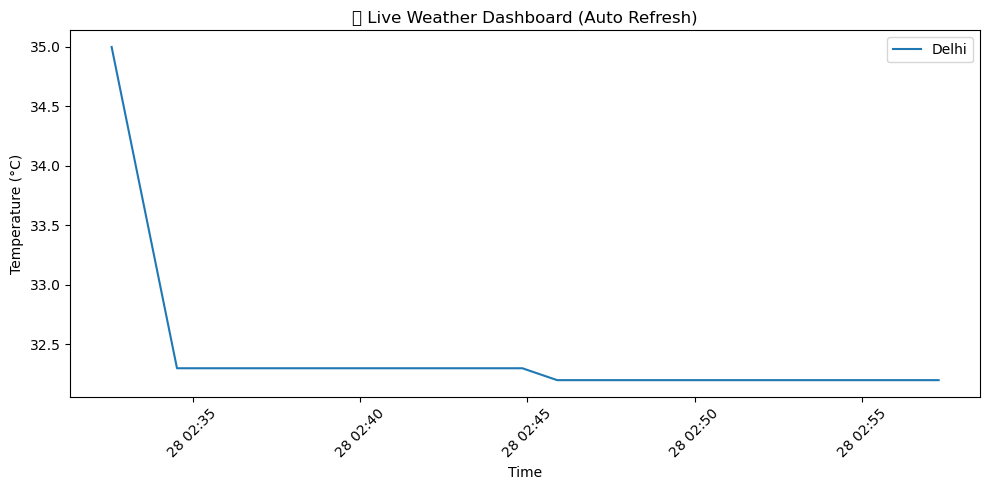

🔄 Dashboard updated


In [ ]:
import pyodbc
import pandas as pd
import matplotlib.pyplot as plt
import time

def load_data():
    conn = pyodbc.connect(
        "DRIVER={ODBC Driver 18 for SQL Server};"
        "SERVER=localhost;"
        "DATABASE=TestDB;"
        "Trusted_Connection=yes;"
        "Encrypt=yes;"
        "TrustServerCertificate=yes;"
    )

    df = pd.read_sql("SELECT * FROM WeatherHistory", conn)
    conn.close()

    return df


def draw_dashboard():
    df = load_data()

    plt.clf()  # clear old graph

    plt.figure(figsize=(10,5))

    for city in df["City"].unique():
        city_data = df[df["City"] == city]
        plt.plot(city_data["WeatherTime"], city_data["Temperature"], label=city)

    plt.title("🌦️ Live Weather Dashboard (Auto Refresh)")
    plt.xlabel("Time")
    plt.ylabel("Temperature (°C)")
    plt.legend()
    plt.xticks(rotation=45)

    plt.tight_layout()
    plt.show()


plt.ion()  # interactive mode ON

while True:
    draw_dashboard()
    print("🔄 Dashboard updated")

    time.sleep(60)  # 10 minutes